In [ ]:
import gpflow as gpf
import tensorflow as tf
import numpy as np
import sys
sys.path.append("../..")
from inducing_variable import LMCInducingPointsBase
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50}, method="L-BFGS-B")
    plt.plot(res["loss_history"])
    plt.show()

def get_kernel():
    return gpf.kernels.Matern32(active_dims=[0])

#### Code reproducing Figure 3 

(200,)


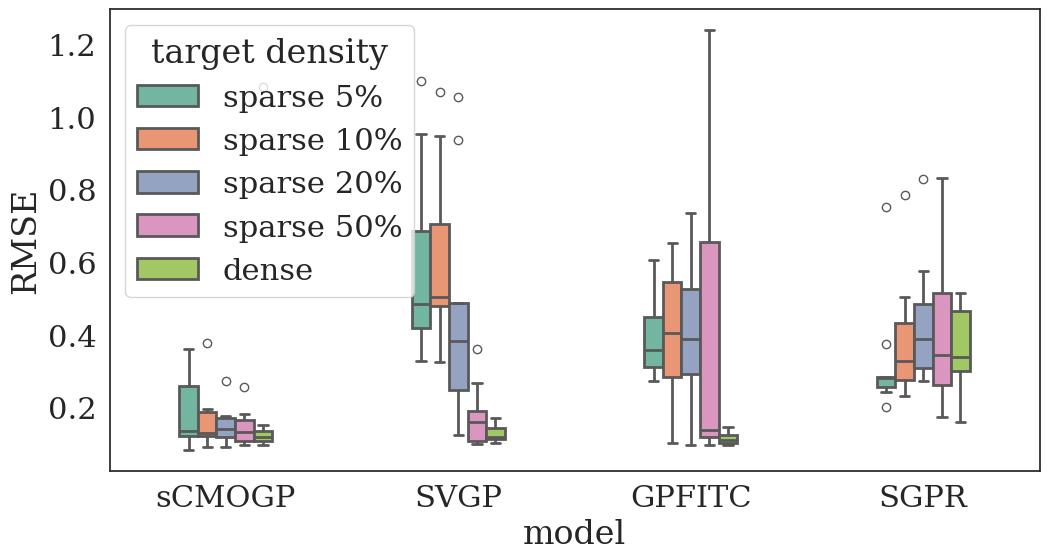

[0.0100569  0.04354828 0.07571771 0.01738099 0.13113415 0.0144532
 0.01674557 0.11602691 0.0190775  0.00683698]
proportion 5
	 PAIR 	 PVAL 	 CORRECTED_PVAL
	 SCMOGP/SVGP 		 0.001953125 	 0.01171875 	 True
	 SCMOGP/GP-FITC 		 0.001953125 	 0.01171875 	 True
	 SCMOGP/SGPR 		 0.01953125 	 0.0390625 	 True
	 SVGP/GP-FITC 		 0.005859375 	 0.017578125 	 True
	 SVGP/SGPR 		 0.001953125 	 0.01171875 	 True
	 GP-FITC/SGPR 		 0.064453125 	 0.064453125 	 False
proportion 10
	 PAIR 	 PVAL 	 CORRECTED_PVAL
	 SCMOGP/SVGP 		 0.001953125 	 0.01171875 	 True
	 SCMOGP/GP-FITC 		 0.00390625 	 0.015625 	 True
	 SCMOGP/SGPR 		 0.009765625 	 0.029296875 	 True
	 SVGP/GP-FITC 		 0.048828125 	 0.09765625 	 False
	 SVGP/SGPR 		 0.001953125 	 0.01171875 	 True
	 GP-FITC/SGPR 		 0.6953125 	 0.6953125 	 False
proportion 20
	 PAIR 	 PVAL 	 CORRECTED_PVAL
	 SCMOGP/SVGP 		 0.005859375 	 0.029296875 	 True
	 SCMOGP/GP-FITC 		 0.005859375 	 0.029296875 	 True
	 SCMOGP/SGPR 		 0.00390625 	 0.0234375 	 True
	 SVGP/GP-FI

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from itertools import combinations

data_50 = np.load("results/toy-example-interpolation-0.5.npz")
data_20 = np.load("results/toy-example-interpolation-0.2.npz")
data_10 = np.load("results/toy-example-interpolation-0.1.npz")
data_05 = np.load("results/toy-example-interpolation-0.05.npz")


sgpr_d = data_10["sgpr"][:,0]
svgp_d = data_10["svgp"][:,0]
scmogp_d = data_10["scmogp"][:,0]
gprfitc_d = data_10["gpfitc"][:,0]
svgp50 = data_50["svgp"][:,1]
scmogp50 = data_50["scmogp"][:,1]
sgpr50 = data_50["sgpr"][:,1]
gprfitc50 = data_50["gpfitc"][:,1]
svgp20 = data_20["svgp"][:,1]
sgpr20 = data_20["sgpr"][:,1]
scmogp20 = data_20["scmogp"][:,1]
gprfitc20 = data_20["gpfitc"][:,1]
svgp10 = data_10["svgp"][:,1]
sgpr10 = data_10["sgpr"][:,1]
scmogp10 = data_10["scmogp"][:,1]
gprfitc10 = data_10["gpfitc"][:,1]
scmogp5 = data_05["scmogp"][:,1]
svgp5 = data_05["svgp"][:,1]
sgpr5 = data_05["sgpr"][:,1]
gprfitc5 = data_05["gpfitc"][:,1]

# Add a dark grid
# Create and display the plot
rmse_stacked = np.sqrt(np.concatenate([scmogp5, svgp5, gprfitc5, sgpr5, scmogp10, svgp10, gprfitc10, sgpr10, scmogp20, svgp20, gprfitc20, sgpr20, scmogp50, svgp50, gprfitc50, sgpr50, scmogp_d, svgp_d, gprfitc_d, sgpr_d ]))
print(rmse_stacked.shape)
names = np.concatenate((["sCMOGP" for i in range(10)], ["SVGP" for i in range(10)], ["GPFITC" for i in range(10)], ["SGPR" for i in range(10)]))
names_stacked = np.concatenate((names, names, names, names, names))
densities = np.concatenate([["sparse 5%" for i in range(40)], ["sparse 10%" for i in range(40)], ["sparse 20%" for i in range(40)], ["sparse 50%" for i in range(40)], ["dense" for i in range(40)]])

df = pd.DataFrame()
df["RMSE"] = rmse_stacked
df["model"] = names_stacked
df["target density"] = densities
plt.figure(figsize=(12, 6))
sns.set_theme(style="white", font="serif", font_scale=2)
sns.boxplot(x="model",
            y="RMSE",
            hue="target density",
            data=df,
            palette="Set2",
            width=0.4, linewidth=2)
plt.show()

print(scmogp5)

rmse_list =[[("SCMOGP", np.sqrt(scmogp5)), ("SVGP", np.sqrt(svgp5)), ("GP-FITC", np.sqrt(gprfitc5)), ("SGPR", np.sqrt(sgpr5))], 
[("SCMOGP", np.sqrt(scmogp10)), ("SVGP", np.sqrt(svgp10)), ("GP-FITC", np.sqrt(gprfitc10)), ("SGPR", np.sqrt(sgpr10))], 
[("SCMOGP", np.sqrt(scmogp20)), ("SVGP", np.sqrt(svgp20)), ("GP-FITC", np.sqrt(gprfitc20)), ("SGPR", np.sqrt(sgpr20))], 
[("SCMOGP", np.sqrt(scmogp50)), ("SVGP", np.sqrt(svgp50)), ("GP-FITC", np.sqrt(gprfitc50)), ("SGPR", np.sqrt(sgpr50))], 
[("SCMOGP", np.sqrt(scmogp_d)), ("SVGP", np.sqrt(svgp_d)), ("GP-FITC", np.sqrt(gprfitc_d)), ("SGPR", np.sqrt(sgpr_d))]]

for proportion, lst in zip(["5", "10", "20", "50", "dense"], rmse_list):
    print(f"proportion {proportion}")
    pvals = []
    order = []
    for (nameA, rA), (nameB, rB) in combinations(lst, 2):
        order.append(f"{nameA}/{nameB}")
        test = wilcoxon(rA, rB)
        pvals.append(test.pvalue)
    reject, corrected_pval, _, _ = multipletests(np.array(pvals), method="holm")

    print("\t PAIR \t PVAL \t CORRECTED_PVAL")
    for names, pval, c_pval, reject in zip(order, pvals, corrected_pval, reject):
        print(f"\t {names} \t\t {pval} \t {c_pval}", "\t", reject)